## **INTEGRANTES**

**- ARTEAGA LEÓN VICKY**

**- BRAVO PIN CRISTHIAN**

**<h1 style="text-align:center; color:purple ; ">BASES DE PROGRAMACIÓN</h1>**

**<h1 style="text-align:center; color:red ; ">PROYECTO: AUTOMATIZACIÓN DE ANÁLISIS Y VISUALIZACIÓN DE DATOS CLIMÁTICOS</h1>**

# **INTRODUCCIÓN**

<div style="text-align: justify;">El análisis de datos climáticos constituye una herramienta fundamental dentro de las geociencias, permitiendo identificar patrones espacio-temporales en variables como la temperatura, la precipitación, la humedad y el viento. El volumen creciente de información meteorológica disponible hace inviable un procesamiento manual, por lo que la automatización mediante lenguajes de programación como Python se ha convertido en una práctica estándar en la ciencia de datos aplicada a las geociencias.
<div style="text-align: justify;">El presente proyecto desarrolla un flujo de trabajo automatizado para la carga, limpieza, análisis exploratorio, manipulación y visualización de un conjunto de datos climáticos correspondiente a diez ciudades de Estados Unidos, registrados entre enero y mayo de 2024. A través del uso de bucles, funciones, estructuras condicionales y las librerías NumPy, Pandas y Matplotlib, se construyó un pipeline que no solo cumple los requerimientos técnicos del curso de Bases de Programación, sino que además incorpora análisis adicionales (segmentación por hora del día, por estación, categorización de variables y series de tiempo comparativas) que permitieron detectar patrones no evidentes en un análisis superficial.

# **OBJETIVOS**

<div style="text-align: justify;">Automatizar el proceso de carga, limpieza, análisis exploratorio, manipulación y visualización de un conjunto de datos climáticos de diez ciudades de Estados Unidos mediante el uso de bucles, funciones y estructuras condicionales en Python, para el mejoramiento de la eficiencia, reproducibilidad y profundidad del análisis.

# **DESCRIPCIÓN DEL CONJUNTO DE DATOS**

<div style="text-align: justify;">El dataset (Weather_Data_1.csv) contiene 1,000,000 de registros y 6 variables originales: ubicación (Location, 10 ciudades), fecha y hora (Date_Time), temperatura en °C, humedad relativa en %, precipitación en mm y velocidad del viento en km/h, con registros entre el 1 de enero y el 18 de mayo de 2024. No se encontraron valores nulos ni filas exactamente duplicadas.
A lo largo del análisis, el DataFrame fue enriquecido con 7 columnas derivadas: Anio y Mes (extraídas de la fecha), Hora (para análisis horario), Estacion (Invierno/Primavera/Verano/Otoño, calculada con condicionales if/elif), Sensacion_Termica_C (calculada combinando temperatura, humedad y viento), Categoria_Lluvia (Ligera/Moderada/Intensa) y Categoria_Viento (Calma/Moderado/Fuerte).

# **ANÁLISIS EXPLORATORIO DE DATOS**

<div style="text-align: justify;">El EDA se automatizó mediante 9 funciones/bloques: cálculo de estadísticas descriptivas con NumPy almacenadas en un diccionario (2.1), identificación del mes con mayor temperatura promedio (2.2) y mayor precipitación acumulada (2.3), la ciudad con mayor velocidad de viento promedio (2.4), un resumen tabular por ciudad (2.5), la extracción de los registros extremos del dataset mediante un diccionario (2.6), un análisis de variación horaria (2.7), un ranking de las ciudades más calurosas (2.8) y la creación de una variable categórica de estación del año (2.9).

# **RESULTADOS**

### **1. CARGA Y PREPARACIÓN DE DATOS**

#### **1.1 Importar librerias**

In [1]:
import pandas as pd
import numpy as np

#### **1.2 Carga de datos**

In [2]:
# Se carga la base de datos

df = pd.read_csv("Weather_Data_1.csv")

print(df)

            Location        Date_Time  Temperature_C  Humidity_pct  \
0          San Diego  1/14/2024 21:12      10.683001     41.195754   
1          San Diego  5/17/2024 15:22       8.734140     58.319107   
2          San Diego   5/11/2024 9:30      11.632436     38.820175   
3       Philadelphia  2/26/2024 17:32      -8.628976     54.074474   
4        San Antonio  4/29/2024 13:23      39.808213     72.899908   
...              ...              ...            ...           ...   
999995        Dallas   1/1/2024 20:29      23.416877     37.705024   
999996   San Antonio  1/20/2024 15:59       6.759080     40.731036   
999997      New York   4/14/2024 8:30      15.664465     62.201884   
999998       Chicago  5/12/2024 20:10      18.999994     63.703245   
999999      New York  4/16/2024 16:11      10.725351     43.804584   

        Precipitation_mm  Wind_Speed_kmh  
0               4.020119        8.233540  
1               9.111623       27.715161  
2               4.607511      

#### **1.3 Dimensiones y Tipos de Datos**

In [3]:
# Se ven las dimensiones originales
df = pd.read_csv("Weather_Data_1.csv")

print("Dimensiones originales:", df.shape)

Dimensiones originales: (1000000, 6)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  str    
 1   Date_Time         1000000 non-null  str    
 2   Temperature_C     1000000 non-null  float64
 3   Humidity_pct      1000000 non-null  float64
 4   Precipitation_mm  1000000 non-null  float64
 5   Wind_Speed_kmh    1000000 non-null  float64
dtypes: float64(4), str(2)
memory usage: 45.8 MB


#### **1.4 Revisar valores nulos**

In [5]:
def revisar_nulos(data):
    return data.isnull().sum()

print(revisar_nulos(df))

Location            0
Date_Time           0
Temperature_C       0
Humidity_pct        0
Precipitation_mm    0
Wind_Speed_kmh      0
dtype: int64


#### **1.5 Revisar duplicados**

In [6]:
# Se revisan los datos duplicados

def revisar_duplicados(data):
    exactos = int(data.duplicated().sum())
    por_clave = int(data.duplicated(subset=["Location", "Date_Time"]).sum())
    print(f"Filas 100% duplicadas: {exactos}")
    print(f"Filas con misma ciudad+fecha pero distinta medición: {por_clave}")
    return exactos, por_clave

revisar_duplicados(df)

Filas 100% duplicadas: 0
Filas con misma ciudad+fecha pero distinta medición: 213531


(0, 213531)

#### **1.6 Eliminar duplicados**

In [7]:
# Se procede a verificar si existen duplicados

def eliminar_duplicados(data):
    n_antes = data.shape[0]
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Filas antes: {n_antes} | Filas después: {data.shape[0]}")
    return data

df = eliminar_duplicados(df)

Filas antes: 1000000 | Filas después: 1000000


#### **1.7 Convertir tipo de datos y extraer datos**

In [8]:
# Se convierten los datos en tiempo y se extraen el año y mes

def convertir_tipos(data):
    data = data.copy()
    data["Date_Time"] = pd.to_datetime(data["Date_Time"], format="%m/%d/%Y %H:%M")
    data["Anio"] = data["Date_Time"].dt.year
    data["Mes"] = data["Date_Time"].dt.month
    data["Location"] = data["Location"].astype("category")
    return data

df = convertir_tipos(df)
df.dtypes

Location                  category
Date_Time           datetime64[us]
Temperature_C              float64
Humidity_pct               float64
Precipitation_mm           float64
Wind_Speed_kmh             float64
Anio                         int32
Mes                          int32
dtype: object

#### **1.8 Resumen estadístico**

In [9]:
# Se realiza un resumen estadístico de las columnas

def resumen_estadistico(data, columnas):
    return data[columnas].describe()

columnas_numericas = ["Temperature_C", "Humidity_pct", "Precipitation_mm", "Wind_Speed_kmh"]
resumen_estadistico(df, columnas_numericas)

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,14.779705,60.021830,5.109639,14.997598
std,14.482558,17.324022,2.947997,8.663556
min,-19.969311,30.000009,0.000009,0.000051
25%,2.269631,45.008500,2.580694,7.490101
50%,14.778002,60.018708,5.109917,14.993777
75%,27.270489,75.043818,7.613750,22.514110
max,39.999801,89.999977,14.971583,29.999973


### **2. Análisis Exploratorio de Datos (EDA)**

#### **2.1 Estadística descriptiva**

In [10]:
# Se realiza la estadística descriptiva y se usa la libreria Numpy 

def estadisticas_descriptivas(data, columnas):
    resultados = {}
    for col in columnas:
        valores = data[col].to_numpy()
        resultados[col] = {
            "media": np.mean(valores),
            "mediana": np.median(valores),
            "desviacion_std": np.std(valores)
        }
    return resultados

stats_dict = estadisticas_descriptivas(df, columnas_numericas)
for col, v in stats_dict.items():
    print(f"{col}: media={v["media"]:.2f}, mediana={v["mediana"]:.2f}, std={v["desviacion_std"]:.2f}")

Temperature_C: media=14.78, mediana=14.78, std=14.48
Humidity_pct: media=60.02, mediana=60.02, std=17.32
Precipitation_mm: media=5.11, mediana=5.11, std=2.95
Wind_Speed_kmh: media=15.00, mediana=14.99, std=8.66


#### **2.2 Temperatura promedio**

In [11]:
# Se calcula la temperatura promedio más alta por mes 

def mes_temp_mas_alta(data):
    temp_por_mes = data.groupby("Mes")["Temperature_C"].mean()
    mes_max = temp_por_mes.idxmax()
    print(f"Mes con temperatura más alta: {mes_max} ({temp_por_mes[mes_max]:.2f} °C)")
    return temp_por_mes.sort_values(ascending=False)

mes_temp_mas_alta(df)

Mes con temperatura más alta: 5 (15.04 °C)


Mes
5    15.042793
3    15.005691
4    15.001603
2    14.502081
1    14.446461
Name: Temperature_C, dtype: float64

#### **2.3 Precipitación acumulada**

In [12]:
# Se calcula el mes con mayor precipitación acumulada 

def mes_mas_precipitacion(data):
    precip_por_mes = data.groupby("Mes")["Precipitation_mm"].sum()
    mes_max = precip_por_mes.idxmax()
    print(f"Mes con más precipitación acumulada: {mes_max} ({precip_por_mes[mes_max]:.0f} mm)")
    return precip_por_mes.sort_values(ascending=False)

mes_mas_precipitacion(df)

Mes con más precipitación acumulada: 1 (1174628 mm)


Mes
1    1.174628e+06
3    1.114472e+06
2    1.093498e+06
4    1.083924e+06
5    6.431172e+05
Name: Precipitation_mm, dtype: float64

#### **2.4 Vientos promedios**

In [13]:
# Se calcula la ciudad que tiene el viento promedio más alto

def ciudad_viento_mas_alto(data):
    viento_por_ciudad = data.groupby("Location")["Wind_Speed_kmh"].mean().sort_values(ascending=False)
    print(f"Ciudad con viento promedio más alto: {viento_por_ciudad.idxmax()} ({viento_por_ciudad.max():.2f} km/h)")
    return viento_por_ciudad

ciudad_viento_mas_alto(df)

Ciudad con viento promedio más alto: San Diego (15.04 km/h)


Location
San Diego       15.037633
Los Angeles     15.035120
Dallas          15.022001
Chicago         14.999501
Philadelphia    14.990663
Houston         14.989935
New York        14.989398
Phoenix         14.983904
San Jose        14.971369
San Antonio     14.956579
Name: Wind_Speed_kmh, dtype: float64

#### **2.5 Tabla resumen por ciudad**

In [14]:
def resumen_por_ciudad(data, columnas):
    return data.groupby("Location")[columnas].mean().round(2)

resumen_por_ciudad(df, columnas_numericas)

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
Location,,,,
Chicago,15.01,60.09,5.00,15.00
Dallas,15.01,59.96,5.00,15.02
Houston,14.94,59.97,5.00,14.99
Los Angeles,15.08,60.07,5.00,15.04
New York,15.01,60.04,4.99,14.99
Philadelphia,15.04,60.04,5.01,14.99
Phoenix,12.79,60.05,6.09,14.98
San Antonio,15.03,59.93,5.01,14.96
San Diego,14.93,60.07,5.01,15.04


#### **2.6 Registros extremos**

In [15]:
# Se crea un diccionario 

def registros_extremos(data):
    extremos = {
        "temp_max": data.loc[data["Temperature_C"].idxmax()],
        "temp_min": data.loc[data["Temperature_C"].idxmin()],
        "precip_max": data.loc[data["Precipitation_mm"].idxmax()],
        "viento_max": data.loc[data["Wind_Speed_kmh"].idxmax()]
    }

# Se aplica el código para el registro

    for nombre, fila in extremos.items():
        print(f"{nombre}: {fila["Location"]} | {fila["Date_Time"]} | Temp={fila["Temperature_C"]:.2f}°C")
    return extremos

registros_extremos(df)

temp_max: New York | 2024-05-16 14:31:00 | Temp=40.00°C
temp_min: Phoenix | 2024-01-12 20:20:00 | Temp=-19.97°C
precip_max: Phoenix | 2024-01-02 00:58:00 | Temp=-0.13°C
viento_max: Philadelphia | 2024-01-25 14:08:00 | Temp=19.91°C


{'temp_max': Location                       New York
 Date_Time           2024-05-16 14:31:00
 Temperature_C                 39.999801
 Humidity_pct                  35.418345
 Precipitation_mm               6.574819
 Wind_Speed_kmh                20.988972
 Anio                               2024
 Mes                                   5
 Name: 899115, dtype: object,
 'temp_min': Location                        Phoenix
 Date_Time           2024-01-12 20:20:00
 Temperature_C                -19.969311
 Humidity_pct                  52.217649
 Precipitation_mm               0.554449
 Wind_Speed_kmh                 21.77262
 Anio                               2024
 Mes                                   1
 Name: 360894, dtype: object,
 'precip_max': Location                        Phoenix
 Date_Time           2024-01-02 00:58:00
 Temperature_C                 -0.125291
 Humidity_pct                  79.288523
 Precipitation_mm              14.971583
 Wind_Speed_kmh                22.641603


#### **2.7 Análisis por hora**

In [16]:
# Se realiza un análisis por hora del día 

df["Hora"] = df["Date_Time"].dt.hour
temp_por_hora = df.groupby("Hora")["Temperature_C"].mean()
print("Hora más calurosa:", temp_por_hora.idxmax(), f"({temp_por_hora.max():.2f}°C)")
print("Hora más fría:", temp_por_hora.idxmin(), f"({temp_por_hora.min():.2f}°C)")

Hora más calurosa: 21 (14.87°C)
Hora más fría: 11 (14.64°C)


#### **2.8 Ciudades más calurosas**

In [17]:
# Se calcula el top 3 de las ciudades más calurosas

df.groupby("Location")["Temperature_C"].mean().sort_values(ascending=False).head(3)

Location
Los Angeles     15.081063
Philadelphia    15.035892
San Antonio     15.027761
Name: Temperature_C, dtype: float64

#### **2.9 Columna Estación**

In [18]:
# Se visualizan las columnas

print(df.columns)

Index(['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct',
       'Precipitation_mm', 'Wind_Speed_kmh', 'Anio', 'Mes', 'Hora'],
      dtype='str')


In [19]:
# Creación de la columna Estación

def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"

df["Estacion"] = df["Mes"].apply(asignar_estacion)
print(df.head())

       Location           Date_Time  Temperature_C  Humidity_pct  \
0     San Diego 2024-01-14 21:12:00      10.683001     41.195754   
1     San Diego 2024-05-17 15:22:00       8.734140     58.319107   
2     San Diego 2024-05-11 09:30:00      11.632436     38.820175   
3  Philadelphia 2024-02-26 17:32:00      -8.628976     54.074474   
4   San Antonio 2024-04-29 13:23:00      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  Anio  Mes  Hora   Estacion  
0          4.020119        8.233540  2024    1    21   Invierno  
1          9.111623       27.715161  2024    5    15  Primavera  
2          4.607511       28.732951  2024    5     9  Primavera  
3          3.183720       26.367303  2024    2    17   Invierno  
4          9.598282       29.898622  2024    4    13  Primavera  


### **3. Manipulación de datos (Pandas)**

#### **3.1 Agrupación de columnas**

In [20]:
# Se agrupan las columnas por ciudad y mes

def agrupar_ciudad_mes(data):
    return data.groupby(["Location", "Mes"]).agg(
        Temp_promedio=("Temperature_C", "mean"),
        Precip_total=("Precipitation_mm", "sum"),
        Viento_max=("Wind_Speed_kmh", "max"),
        N_registros=("Temperature_C", "count")
    ).round(2)

agrupar_ciudad_mes(df).head(10)

Temp_promedio  Precip_total  Viento_max  N_registros
Location Mes                                                      
Chicago  1            14.86     111942.41        30.0        22334
         2            15.12     103658.33        30.0        20808
         3            15.08     112656.70        30.0        22405
         4            15.09     107304.81        30.0        21572
         5            14.85      65574.68        30.0        13045
Dallas   1            14.94     111488.25        30.0        22249
         2            14.98     104997.86        30.0        21065
         3            14.83     110494.98        30.0        22273
         4            15.16     108502.67        30.0        21519
         5            15.24      63947.16        30.0        12830

#### **3.2 Filtro percentil**

In [21]:
# Se filtra la precipitación alta según los registros

def filtrar_precipitacion_alta(data, percentil=90):
    umbral = np.percentile(data["Precipitation_mm"], percentil)
    filtrado = data.loc[data["Precipitation_mm"] >= umbral]
    print(f"Umbral percentil {percentil}: {umbral:.2f} mm | Registros filtrados: {filtrado.shape[0]}")
    return filtrado

filtrado_lluvia = filtrar_precipitacion_alta(df)
print(filtrado_lluvia["Location"].value_counts())

# Filtrado adicional con query() e isin()

ciudades_costeras = ["San Diego", "Los Angeles", "New York"]
filtrado_costero = df.query("Location in @ciudades_costeras and Mes <= 2")
print(f"Ciudades costeras en enero-febrero: {filtrado_costero.shape[0]} registros")

Umbral percentil 90: 9.11 mm | Registros filtrados: 100000
Location
Phoenix         19766
San Antonio      9049
Philadelphia     9041
Chicago          8952
Houston          8952
San Diego        8908
San Jose         8891
Los Angeles      8863
New York         8807
Dallas           8771
Name: count, dtype: int64
Ciudades costeras en enero-febrero: 129463 registros


#### **3.3 Sensación térmica**

In [22]:
# Se calcula la sensación térmica a partir de la temperatura y la humedad

def calcular_sensacion_termica(data):
    data = data.copy()
    e = (data["Humidity_pct"] / 100) * 6.105 * np.exp(17.27 * data["Temperature_C"] / (237.7 + data["Temperature_C"]))
    data["Sensacion_Termica_C"] = data["Temperature_C"] + 0.33 * e - 0.70 * data["Wind_Speed_kmh"] - 4.00
    return data

df = calcular_sensacion_termica(df)
df["Sensacion_Termica_C"].describe().round(2)

count    1000000.00
mean           4.94
std           19.24
min          -43.72
25%          -10.72
50%            3.71
75%           19.96
max           57.30
Name: Sensacion_Termica_C, dtype: float64

#### **3.4 Matriz de correlación**

In [23]:
# Se realiza una matriz de correlación a partir de diferentes parámetros

def matriz_correlacion(data, columnas):
    return data[columnas].corr().round(4)

columnas_corr = ["Temperature_C", "Humidity_pct", "Precipitation_mm", "Wind_Speed_kmh", "Sensacion_Termica_C"]
matriz_correlacion(df, columnas_corr)

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Sensacion_Termica_C
Temperature_C,1.0000,-0.0013,-0.0109,-0.0013,0.9424
Humidity_pct,-0.0013,1.0000,-0.0003,-0.0006,0.0689
Precipitation_mm,-0.0109,-0.0003,1.0000,0.0010,-0.0106
Wind_Speed_kmh,-0.0013,-0.0006,0.0010,1.0000,-0.3166
Sensacion_Termica_C,0.9424,0.0689,-0.0106,-0.3166,1.0000


#### **3.5 Tabla de contigencia**

In [25]:
# Se realiza una tabla de contingencia con la categoría lluvia y precipitación

def categoria_lluvia(mm):
    if mm < 3:
        return "Ligera"
    elif mm < 8:
        return "Moderada"
    else:
        return "Intensa"

df["Categoria_Lluvia"] = df["Precipitation_mm"].apply(categoria_lluvia)
pd.crosstab(df["Location"], df["Categoria_Lluvia"])

Categoria_Lluvia,Intensa,Ligera,Moderada
Location,,,
Chicago,20039,30037,50088
Dallas,19872,30001,50063
Houston,20052,30226,49798
Los Angeles,20047,29925,49950
New York,20018,30168,49786
Philadelphia,20170,30146,49806
Phoenix,30956,20860,48393
San Antonio,20105,29878,49979
San Diego,19943,29699,50132


#### **3.6 Categoría por viento**

In [26]:
# Se calcula la categoría de viento

def categoria_viento(v):
    if v < 10:
        return "Calma"
    elif v < 20:
        return "Moderado"
    else:
        return "Fuerte"

df["Categoria_Viento"] = df["Wind_Speed_kmh"].apply(categoria_viento)
df["Categoria_Viento"].value_counts()

Categoria_Viento
Fuerte      333516
Calma       333315
Moderado    333169
Name: count, dtype: int64

#### **3.7 Exportar datos a excel**

In [27]:
# Exportar la base a un archivo excel 

def exportar_excel(data, nombre_archivo, n_muestra=20000):
    # Excel soporta máx. 1,048,576 filas; con 1,000,000 de registros se exporta una muestra representativa
    muestra = data.sample(n_muestra, random_state=42)
    muestra.to_excel(nombre_archivo, index=False, engine='openpyxl')
    print(f"Archivo exportado: {nombre_archivo} ({muestra.shape[0]} filas)")

exportar_excel(df, "Weather_Data_1.1.xlsx")

Archivo exportado: Weather_Data_1.1.xlsx (20000 filas)


### **4. Visualización de datos**

#### **4.1 Histograma de temperatura**

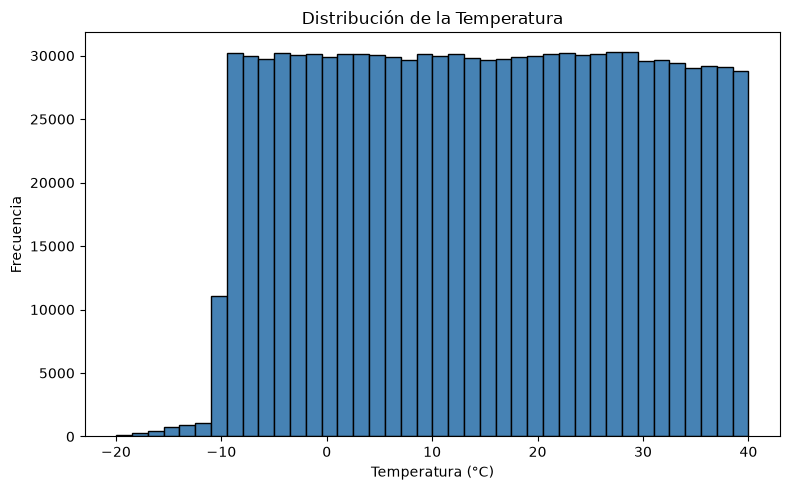

In [28]:
# Se importa la libreria Matplotlib

import matplotlib.pyplot as plt

# Se le agrega el código para el histograma por temperatura

def graficar_histograma_temeratura(data):
    plt.figure(figsize=(8, 5))
    plt.hist(data["Temperature_C"], bins=40, color="steelblue", edgecolor="black")
    plt.title("Distribución de la Temperatura")
    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

graficar_histograma_temperatura(df)

#### **4.2 Temperatura por ciudad**

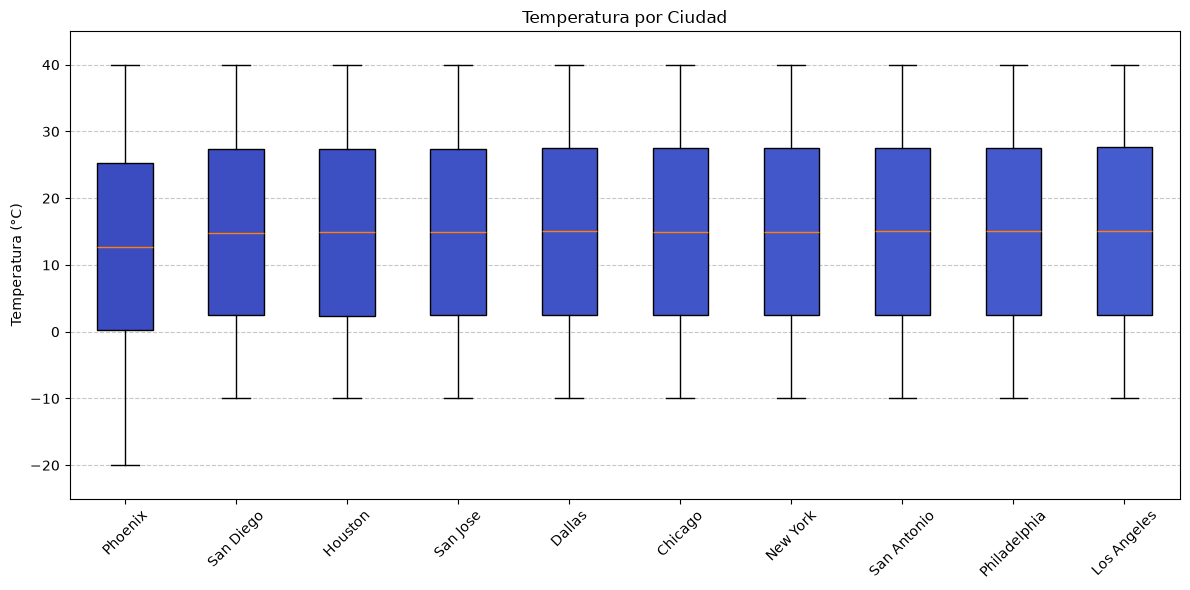

In [39]:
import matplotlib.pyplot as plt

def graficar_boxplot_por_ciudad(data):

# Obtener lista de ciudades y ordenarlas por temperatura promedio
    
    ciudades = sorted(
        data["Location"].unique().tolist(),
        key=lambda c: data.loc[data["Location"] == c, "Temperature_C"].mean()
    )

# Crear lista de temperaturas por ciudad
    
    datos = [data.loc[data["Location"] == c, "Temperature_C"] for c in ciudades]

# Configurar figura y colores
    
    plt.figure(figsize=(12, 6))
    colores = plt.cm.coolwarm(range(len(ciudades)))  # paleta de colores

# Dibujar boxplot con colores
    
    box = plt.boxplot(datos, patch_artist=True)
    for patch, color in zip(box["boxes"], colores):
        patch.set_facecolor(color)

# Etiquetas y formato
    
    plt.xticks(range(1, len(ciudades) + 1), ciudades, rotation=45)
    plt.title("Temperatura por Ciudad")
    plt.ylabel("Temperatura (°C)")
    plt.ylim(-25, 45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

# Ejecutar función

graficar_boxplot_por_ciudad(df)


#### **4.3 Precipitación acumulada**

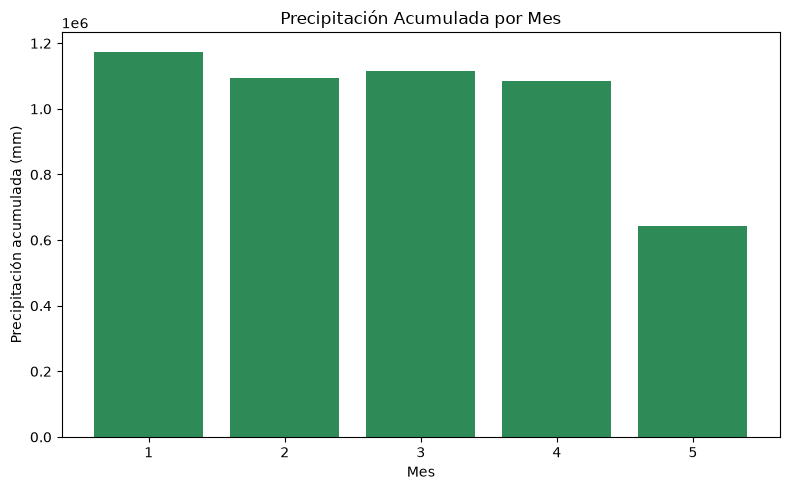

In [40]:
#Se genera un gráfico de precipitación acumulada por mes

def graficar_barras_precipitacion_mensual(data):
    precip_mes = data.groupby("Mes")["Precipitation_mm"].sum()
    plt.figure(figsize=(8, 5))
    plt.bar(precip_mes.index.astype(str), precip_mes.values, color="seagreen")
    plt.title("Precipitación Acumulada por Mes")
    plt.xlabel("Mes")
    plt.ylabel("Precipitación acumulada (mm)")
    plt.tight_layout()
    plt.show()

graficar_barras_precipitacion_mensual(df)

#### **4.4 Temperatura vs Sensación térmica**

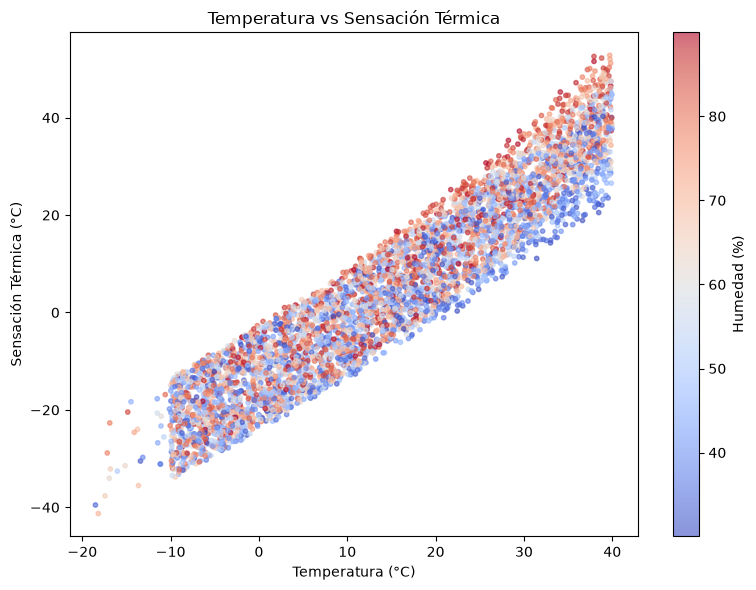

In [41]:
# Se gráfica la temeperatura vs la sensación térmica tomando en cuenta la humedad

def graficar_scatter_temp_sensacion(data, n_muestra=5000):

# se usa una muestra de 5,000 puntos por rendimiento (el dataset tiene 1,000,000 de filas)
    
    muestra = data.sample(n_muestra, random_state=42)
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(muestra["Temperature_C"], muestra["Sensacion_Termica_C"],
                      c=muestra["Humidity_pct"], cmap="coolwarm", alpha=0.6, s=10)
    plt.colorbar(sc, label="Humedad (%)")
    plt.title("Temperatura vs Sensación Térmica")
    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Sensación Térmica (°C)")
    plt.tight_layout()
    plt.show()

graficar_scatter_temp_sensacion(df)

#### **4.5 Histograma por ciudad**

In [46]:
import os

def graficar_histogramas_por_ciudad(data, carpeta="graficos_ciudades"):
    os.makedirs(carpeta, exist_ok=True)
    ciudades = data["Location"].unique()
    for ciudad in ciudades:
        subset = data.loc[data["Location"] == ciudad, "Temperature_C"]
        plt.figure(figsize=(6, 4))
        plt.hist(subset, bins=30, color="darkorange", edgecolor="black")
        plt.title(f"Distribución de Temperatura - {ciudad}")
        plt.xlabel("Temperatura (°C)")
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.savefig(f"{carpeta}/temp_{ciudad.replace(" ", "_")}.png", dpi=100)
        plt.close()
    print(f"Se generaron {len(ciudades)} gráficos en la carpeta '{carpeta}'")

graficar_histogramas_por_ciudad(df)

Se generaron 10 gráficos en la carpeta 'graficos_ciudades'


#### **4.6 Correlación entre variables**

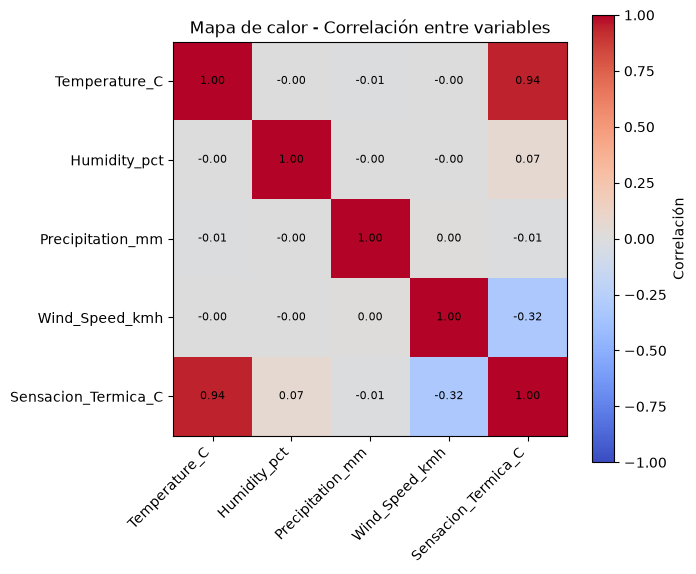

In [47]:
# Se correlaciona los parámetros de temperatura, precipitación, sensación térmica y viento

corr = df[["Temperature_C","Humidity_pct","Precipitation_mm","Wind_Speed_kmh","Sensacion_Termica_C"]].corr()
plt.figure(figsize=(7,6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlación")
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Mapa de calor - Correlación entre variables")
plt.tight_layout()
plt.show()

#### **4.7 Tendencias temporales**

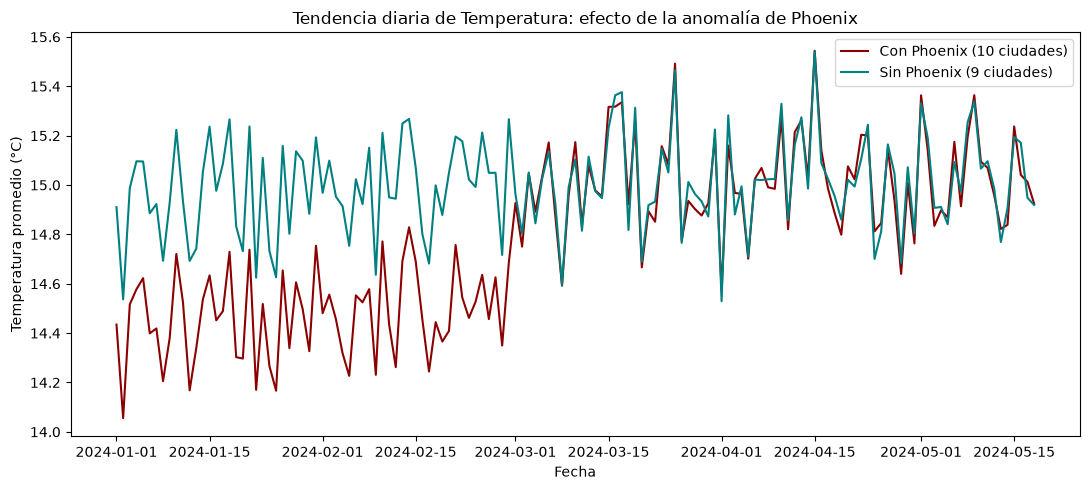

Media enero sin Phoenix: 14.95
Media mayo sin Phoenix: 15.05


In [48]:
# Se calcula la serie temporal más el efecto de la ciudad phoenix

serie_todas = df.set_index("Date_Time").resample("D")["Temperature_C"].mean()
serie_sin_phx = df[df["Location"] != "Phoenix"].set_index("Date_Time").resample("D")["Temperature_C"].mean()

# Se le da forma al gráfico
plt.figure(figsize=(11,5))
plt.plot(serie_todas.index, serie_todas.values, label="Con Phoenix (10 ciudades)", color="darkred")
plt.plot(serie_sin_phx.index, serie_sin_phx.values, label="Sin Phoenix (9 ciudades)", color="teal")
plt.title("Tendencia diaria de Temperatura: efecto de la anomalía de Phoenix")
plt.xlabel("Fecha"); plt.ylabel("Temperatura promedio (°C)")
plt.legend()
plt.tight_layout()
plt.show()

# Se imprime el resultado
print("Media enero sin Phoenix:", serie_sin_phx["2024-01"].mean().round(2))
print("Media mayo sin Phoenix:", serie_sin_phx["2024-05"].mean().round(2))

#### **4.8 Visualización de la base**

In [58]:
# Se muestran las columnas

print(df.head(10))

       Location           Date_Time  Temperature_C  Humidity_pct  \
0     San Diego 2024-01-14 21:12:00      10.683001     41.195754   
1     San Diego 2024-05-17 15:22:00       8.734140     58.319107   
2     San Diego 2024-05-11 09:30:00      11.632436     38.820175   
3  Philadelphia 2024-02-26 17:32:00      -8.628976     54.074474   
4   San Antonio 2024-04-29 13:23:00      39.808213     72.899908   
5     San Diego 2024-01-21 08:54:00      27.341055     49.023236   
6      San Jose 2024-01-13 02:10:00       1.881883     65.742325   
7      New York 2024-01-25 19:04:00      -6.894766     30.804894   
8      New York 2024-03-29 05:20:00       0.963545     38.819158   
9      San Jose 2024-05-18 09:14:00      -1.607088     82.198701   

   Precipitation_mm  Wind_Speed_kmh  Anio  Mes  Hora   Estacion  \
0          4.020119        8.233540  2024    1    21   Invierno   
1          9.111623       27.715161  2024    5    15  Primavera   
2          4.607511       28.732951  2024    5    

# **CONCLUSIONES**

<div style="text-align: justify;">Se logró automatizar exitosamente el flujo de carga, limpieza, EDA, manipulación y visualización mediante funciones reutilizables y bucles, evidenciando los beneficios de la programación estructurada frente a un análisis manual repetitivo.
El dataset, con 1,000,000 de observaciones de 10 ciudades entre enero y mayo de 2024, no presentó valores nulos ni duplicados exactos, y el análisis por hora del día mostró una variación mínima (apenas 0.23°C entre la hora más cálida y la más fría), lo que sugiere que los datos no replican un ciclo día/noche real.
La matriz de correlación mostró coeficientes cercanos a cero entre las variables originales (temperatura, humedad, precipitación, viento), mientras que la columna derivada de sensación térmica sí mostró correlaciones físicamente coherentes (0.94 con temperatura, -0.32 con viento), validando que la fórmula aplicada tiene sentido físico aun cuando los datos base no lo tengan.
Phoenix se identificó como un caso atípico: concentra la totalidad de los registros de la categoría "Intensa" de precipitación y, mediante la comparación de series de tiempo con y sin esta ciudad, se demostró que la aparente tendencia de calentamiento entre enero y mayo es producto de la anomalía de Phoenix en sus dos primeros meses, y no de un patrón estacional real.
La categorización de viento mostró una distribución casi perfectamente equitativa entre las categorías Calma, Moderado y Fuerte (~33% cada una), reforzando la hipótesis de que las variables fueron generadas de forma aleatoria e independiente.

# **RECOMENDACIONES**

<div style="text-align: justify;">Para análisis climáticos con fines investigativos reales, validar el origen del dataset o utilizar fuentes oficiales (NOAA, INAMHI, AEMET) que garanticen relaciones físicas coherentes entre variables.
Ampliar el periodo temporal disponible (actualmente 4.5 meses) para permitir un verdadero análisis estacional, ya que la función asignar_estacion() está preparada para las 4 estaciones, ya que los datos actuales solo cubren Invierno y Primavera.
También se recomienda explorar las librerias Seaborn o Plotly para enriquecer aún más las visualizaciones.

# **REFERENCIAS BIBLIOGRÁFICAS**

**1.** Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... & Oliphant, T. E. (2020). Array programming with NumPy. Nature, 585(7825), 357–362.

**2.** Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.

**3.** McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 56–61.

**4.** Steadman, R. G. (1994). Norms of apparent temperature in Australia. Australian Meteorological Magazine, 43, 1–16.

**5.** Unpingco, J. (2021). Python Programming for Data Analysis. Springer.

**6.** Zelle, J. M. (2010). Python Programming: An Introduction to Computer Science (2nd ed.). Franklin, Beedle & Associates Inc.

**7.** The pandas development team. (2024). pandas documentation. https://pandas.pydata.org/docs/